In [2]:
from datascience import * 
import numpy as np
import matplotlib.pyplot as plots
path_data = '../../data/data8/'
%matplotlib inline
plots.style.use('fivethirtyeight')

# Decision making and uncertainty
Assessing models fall under statistical and computation methodologies that themselves fit into a general decision-making framework known as _statistical tests of hypotheses_.

## Mendel’s Model

For every plant, there is a 75% chance that it will have purple flowers, and a 25% chance that the flowers will be white, regardless of the colors in all the other plants.

To see whether his model was valid, Mendel grew 929 pea plants of this variety. Among these 929 plants, 705 had purple flowers.

We will use these data to perform a test of hypotheses and see if Mendel’s model looks good.

### Step 1: The Hypotheses
All statistical tests attempt to choose between two views of the world. Specifically, the choice is between two views about how the data were generated. These two views are called hypotheses.

**The null hypothesis.** This is a clearly defined model about chances. It says that the data were generated at random under clearly specified assumptions about the randomness. The word “null” reinforces the idea that if the data look different from what the null hypothesis predicts, the difference is due to _nothing_ but chance.

From a practical perspective, **the null hypothesis is a hypothesis under which you can simulate data**.

In the example about Mendel’s model for the colors of pea plants, the null hypothesis is that the assumptions of his model are good: each plant has a 75% chance of having purple flowers, independent of all other plants.

**The alternative hypothesis**. This says that some reason other than chance made the data differ from the predictions of the model in the null hypothesis.

In the example about Mendel’s plants, the alternative hypothesis is simply that his model isn’t good.

### Step 2: The Test Statistic
In order to decide between the two hypothesis, we must choose a statistic that we can use to make the decision. This is called the test statistic.

We will be comparing two categorical distributions: the one in Mendel’s model and the one we will get in our random sample. We want to see if these two distributions are close to each other or far apart. So a natural test statistic is the total variation distance (TVD) developed in the previous section.

By a bit of math that we won’t do here, this is true whenever there are just two categories: the TVD is equal to the distance between the two proportions in one category.

This test statistic is a distance between the two distributions. It makes sense and is easy to use. A sample percent of around 75% will be consistent with the model, but percents much bigger or much less than 75 will make you think that the model isn’t good. 

Therefore, small values of the distance will make you lean towards the null hypothesis. Big values of the statistic will make you lean towards the alternative.

To choose a test statistic in other situations, look at the alternative hypothesis. What values of the statistic will make you think that the alternative hypothesis is a better choice than the null?

- If the answer is “big values,” you have a good choice of statistic.

- So also if the answer is “small values.”

- But if the answer is “both big values and small values,” we recommend that you look again at your statistic. See if using a distance instead of a difference can change the answer to just “big values”.

### Step 3: The Distribution of the Test Statistic Under the Null Hypothesis
The main computational aspect of a test of hypotheses is figuring out what the model in the null hypothesis predicts. Specifically, we have to figure out _what the values of the test statistic might be if the null hypothesis were true_.

By simulating the statistic repeatedly, we get a good sense of its possible values and which ones are more likely than others. In other words, we get a good approximation to the probability distribution of the statistic, as predicted by the model in the null hypothesis.

### Observed Value of the Test Statistic
The observed value of the test statistic is the value of the statistic you get from the data in the study, not a simulated value. Among Mendel’s 929 plants, 705 had purple flowers. The observed value of the test statistic was therefore

In [3]:
observed_statistic = abs ( 100 * (705 / 929) - 75)
observed_statistic

0.8880516684607045

In [4]:
mendel_proportions = make_array(0.75, 0.25)
mendel_proportion_purple = mendel_proportions.item(0)
sample_size = 929

In [5]:
def one_simulated_distance():
    sample_proportion_purple = sample_proportions(sample_size, mendel_proportions).item(0)
    return 100 * abs(sample_proportion_purple - mendel_proportion_purple)

In [6]:
repetitions = 10_000
distances = make_array()
for i in np.arange(repetitions):
    distances = np.append(distances, one_simulated_distance())

In [7]:
len(distances), distances

(10000,
 array([ 1.04951561,  0.34983854,  1.74919268, ...,  1.53390743,
         0.08073197,  1.64155005]))

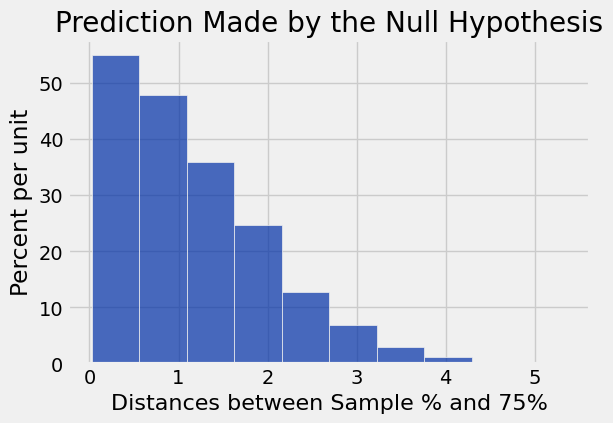

In [8]:
Table().with_column(
    "Distances between Sample % and 75%", distances).hist()
plots.title("Prediction Made by the Null Hypothesis");

The values on the horizontal axis show the distances and the frequency, indicating that the most fall between 0 and 1 such that for a high proportion of the samples the percentage of purple-flowering plants is in 75% $\pm$ 1%. That is to say that the sample percent is in the range 74% to 76%.

This prediction is based on the model only. In the next steps, we'll compare the predictions and Mendel's observations.

### Step 4. The Conclusion of the Test


The choice between the null and alternative hypotheses depends on the comparison between what you computed in Steps 2 and 3: the observed value of the test statistic and its distribution as predicted by the null hypothesis.

If the two are not consistent with each other, then the data do not support the null hypothesis. In other words, the alternative hypothesis is better supported by the data. We say that the test rejects the null hypothesis.

If the two are consistent with each other, then the observed test statistic is in line with what the null hypothesis predicts. In other words, the null hypothesis is better supported by the data. We say that the data are consistent with the null hypothesis.

Here, the observed value of the test statistic is about 0.89, as computed in Step 2 above. Just by eye, locate roughly where 0.89 is on the horizontal axis of the histogram. You will see that it is clearly in the heart of the distribution predicted by Mendel’s model.

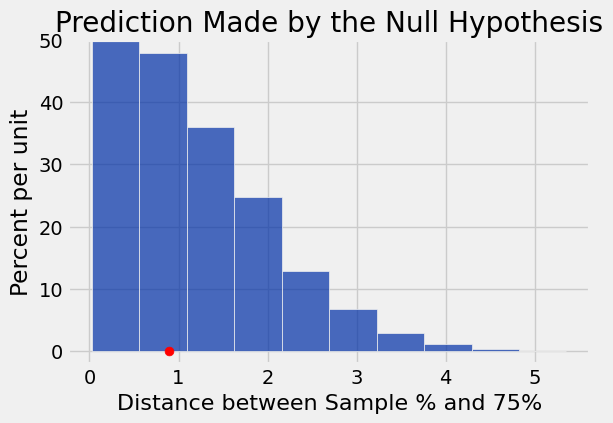

In [9]:
# redraw the histogram with the observed value on the horizontal axis
Table().with_column(
    'Distance between Sample % and 75%', distances
).hist()
plots.ylim(-0.02, 0.5)
plots.title('Prediction Made by the Null Hypothesis')
plots.scatter(observed_statistic, 0, color='red', s=40);

The observed statistic is like a typical distance predicted by the null hypothesis. The null hypothesis is Mendel’s model. So our test concludes that the data are consistent with Mendel’s model.

Based on our data, Mendel’s model looks good.

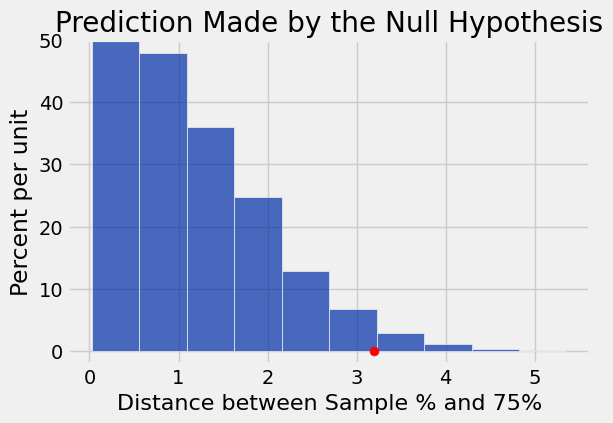

In [10]:
different_observed_statistic = 3.2
Table().with_column(
    'Distance between Sample % and 75%', distances
).hist()
plots.ylim(-0.02, 0.5)
plots.title('Prediction Made by the Null Hypothesis')
plots.scatter(different_observed_statistic, 0, color='red', s=40);

Remember that in a histogram, area represents percent. To find the area in the tail, we have to find the percent of distances that were greater than or equal to 3.2, where the red dot is. The array distances contains the averages for all 10,000 repetitions of random sampling under Mendel’s model, and different_observed_statistic is 3.2.

In [11]:
np.count_nonzero(distances >= different_observed_statistic) / repetitions

0.026599999999999999

## Conventional Cut-offs and the P-value

If you don’t want to use your own judgment, there are conventions that you can follow. These conventions tell us how far out into the tails is conventionally considered “too far”.

The conventions are based on the area in the tail, starting at the observed statistic (the red dot) and looking in the direction that makes us lean toward the alternative. In this example that’s the right side, because big distances favor the alternative which says that the model isn’t good.

If the area of the tail is small, the observed statistic is far away from the values most commonly predicted by the null hypothesis.

## The p-Value

This chance has an impressive name. It is called the observed significance level of the test. That’s a mouthful, and so it is commonly called the p-value of the test.

Definition: The p-value of a test is the chance, based on the model in the null hypothesis, that the test statistic will be equal to the observed value in the sample or even further in the direction that supports the alternative.

If a p-value is small, that means the tail beyond the observed statistic is small and so the observed statistic is far away from what the null predicts. This implies that the data support the alternative hypothesis more than they support the null.

How small is “small”? According to the conventions:

    If the p-value is less than 5%, it is considered small and the result is called “statistically significant.”

    If the p-value is even smaller – less than 1% – the result is called “highly statistically significant.”

By this convention, our p-value of 2.65% is considered small. So the conventional conclusion would be to reject the null hypothesis and say that Mendel’s model does not look good for the new plants. Formally, the result of the test is statistically significant.

When you make a conclusion in this way, we recommend that you don’t just say whether or not the result is statistically significant. Along with your conclusion, provide the observed statistic and the p-value as well, so that readers can use their own judgment.



## Conclusion

Whether you use a conventional cutoff or your own judgment, it is important to keep the following points in mind.

- Always provide the observed value of the test statistic and the p-value, so that readers can decide whether or not they think the p-value is small.

- Don’t look to defy convention only when the conventionally derived result is not to your liking.

- Even if a test concludes that the data don’t support the chance model in the null hypothesis, it typically doesn’t explain why the model doesn’t work. Don’t make causal conclusions without further analysis, unless you are running a randomized controlled trial. 